# Лабораторная работа "определение музыкальных трезвучий"

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os
from scipy.signal import welch, find_peaks

### Выгружаем файл

In [2]:
samplerate, data = wavfile.read('Audio files/DTLab10.wav')

### Визуализируем сигнал

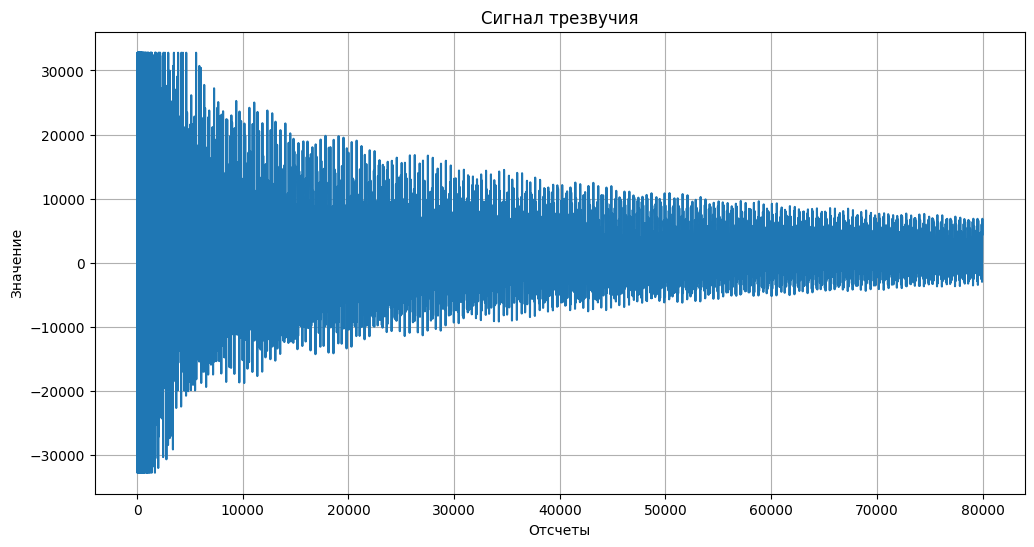

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(data)
plt.title("Сигнал трезвучия")
plt.xlabel("Отсчеты")      
plt.ylabel("Значение")    
plt.grid(True)             

plt.show()

### Вычисляем спектр сигнала

In [4]:
f, Pxx = welch(data, fs=samplerate, nperseg=8192)

# Переводим в децибеллы
spectrum_db = 10 * np.log10(Pxx + 1e-10)

### Строим полный спектр

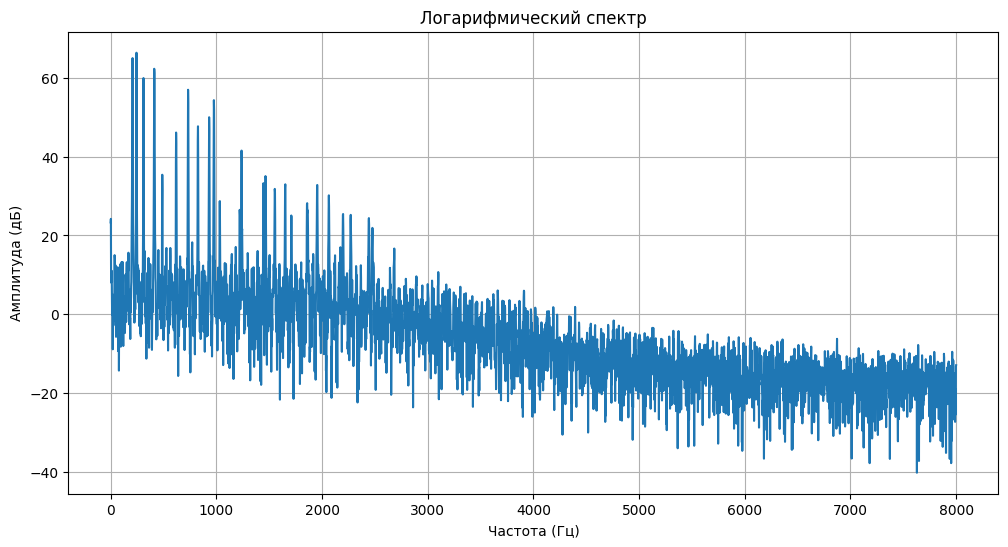

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(f, spectrum_db)
plt.title("Логарифмический спектр")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда (дБ)")
plt.grid(True)
plt.show()



По данному графику сложно определить первые пики. Построим новый график, ограничив частоты сверху:

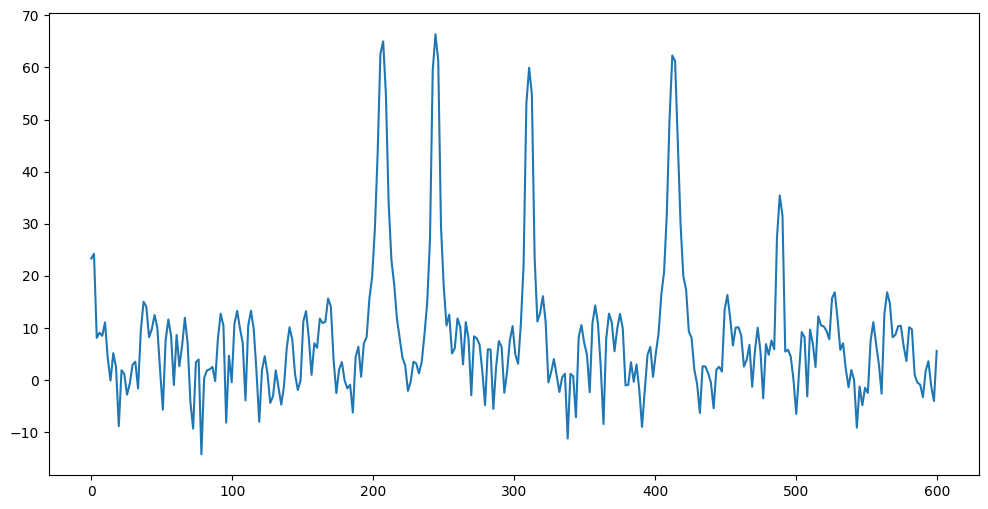

In [6]:
plt.figure(figsize=(12, 6))

limit_freq = 600
mask = f < limit_freq
f_sub = f[mask]
db_sub = spectrum_db[mask]

plt.plot(f_sub, db_sub)

На представленном графике видны три первых пика. Найдем их точные значения

### Найдем пики

При поиске пиков устанавливаем минимальное расстояние между пиками, чтобы не ловить двойные вершины

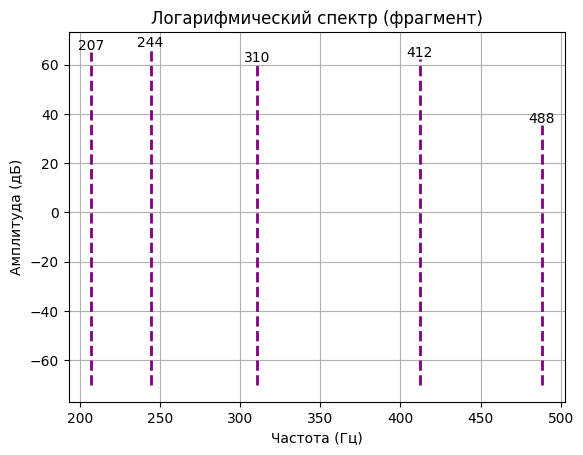

In [19]:
peaks, properties = find_peaks(db_sub, height=30, distance=10)

plt.vlines(x=f_sub[peaks], ymin=-70, ymax=db_sub[peaks], color='purple', linestyle='--', lw=2)

for p in peaks:
    plt.text(f_sub[p], db_sub[p] + 1, f"{int(f_sub[p])}", horizontalalignment='center')

plt.title("Логарифмический спектр (фрагмент)")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда (дБ)")
plt.grid(True)
plt.show()

Найденные локальные максимумы:

In [8]:
freqs = [207, 244, 310]

Посчитаем для каждой частоты номер ноты:

In [9]:
F0 = 130.82
note_numbers = []

for f in freqs:
    n_float = 12 * np.log2(f / F0)
    n_int = int(round(n_float))
    note_numbers.append(n_int)
    
    print(f"Частота {f} Гц n = {n_float:.2f} Округленно: {n_int}")

Частота 207 Гц n = 7.94 Округленно: 8
Частота 244 Гц n = 10.79 Округленно: 11
Частота 310 Гц n = 14.94 Округленно: 15


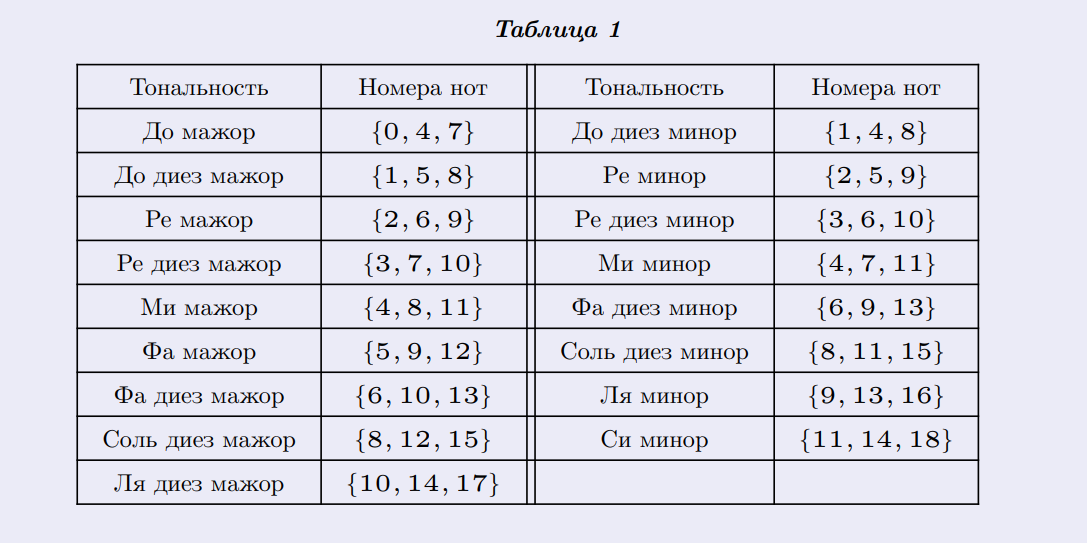

Исходя из таблицы, выявлено трезвучие -  Соль диез минор

Проверим для вторых обертонов:

In [21]:
f_axis, Pxx = welch(data, fs=samplerate, nperseg=8192)
spectrum_db_restored = 10 * np.log10(Pxx + 1e-10)

freqs_found = [207, 244, 310]

Расчитаем теоретические частоты вторых обертонов:

In [20]:
overtones = [fr * 2 for fr in freqs_found]

print(f"Ожидаемые частоты первых обертонов: {overtones}")

Ожидаемые частоты первых обертонов: [414, 488, 620]


### Построим частотный спектр для проверки по первым обертонам:

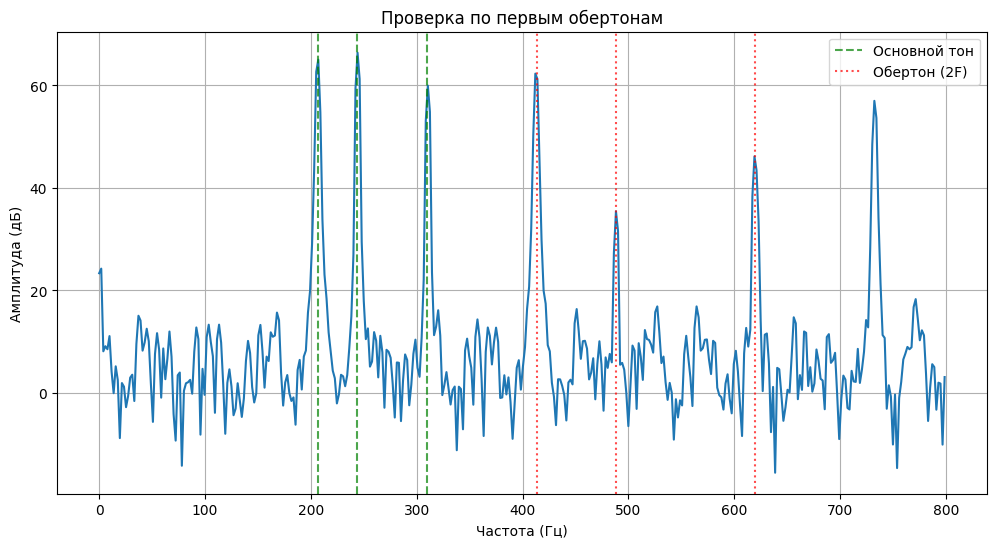

In [25]:
plt.figure(figsize=(12, 6))

limit_freq = 800
mask = f_axis < limit_freq

plt.plot(f_axis[mask], spectrum_db_restored[mask])

for fr in freqs_found:
    plt.axvline(x=fr, color='green', linestyle='--', alpha=0.7, label='Основной тон' if fr == freqs_found[0] else "")

for ov in overtones:
    plt.axvline(x=ov, color='red', linestyle=':', alpha=0.7, label='Обертон (2F)' if ov == overtones[0] else "")

plt.title("Проверка по первым обертонам")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда (дБ)")
plt.legend()
plt.grid(True)
plt.show()

По графику подтверждаем, что первые обертоны 2F1, 2F2, 2F3 совпали с соответствующими пиками.